In [15]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ML and Deep Learning Imports
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [15]:
import pandas as pd
import openpyxl

excel_path = 'predictive_analytics_dataset.xlsx'
xl = pd.ExcelFile(excel_path)
print("Sheet names:", xl.sheet_names)

for sheet in xl.sheet_names:
    df = pd.read_excel(excel_path, sheet_name=sheet)
    print(f"\n--- Sheet: {sheet} ---")
    print(df.info())
    print(df.head(2))

Sheet names: ['Stock_Prices', 'Sales_Data', 'Waiter_Tips']

--- Sheet: Stock_Prices ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2250 entries, 0 to 2249
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2250 non-null   object 
 1   ticker  2250 non-null   object 
 2   open    2250 non-null   float64
 3   high    2250 non-null   float64
 4   low     2250 non-null   float64
 5   close   2250 non-null   float64
 6   volume  2250 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 123.2+ KB
None
         date    ticker    open    high     low   close  volume
0  2023-01-02  TECHCORP  151.00  152.11  149.72  150.18  955304
1  2023-01-03  TECHCORP  149.19  149.24  148.18  148.85  722901

--- Sheet: Sales_Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Load and isolate the data
excel_path = 'predictive_analytics_dataset.xlsx'
stock_df = pd.read_excel(excel_path, sheet_name='Stock_Prices', parse_dates=['date'])
techcorp = stock_df[stock_df['ticker'] == 'TECHCORP'].sort_values('date').reset_index(drop=True)
prices = techcorp['close'].values.reshape(-1, 1)

# 2. Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# 3. Create the sliding window
WINDOW = 20
X_seq, y_seq = [], []
for i in range(WINDOW, len(scaled_prices)):
    X_seq.append(scaled_prices[i-WINDOW:i, 0])
    y_seq.append(scaled_prices[i, 0])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

# 4. Perform the time-based train/test split
split_idx = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:split_idx], X_seq[split_idx:]
y_train_lstm, y_test_lstm = y_seq[:split_idx], y_seq[split_idx:]

print(f"Training data shape: {X_train_lstm.shape}")

Training data shape: (584, 20, 1)


In [9]:
# Custom Model Choice: LSTM with Dropout to prevent overfitting on financial noise
lstm_model = Sequential([
    LSTM(50, activation='relu', return_sequences=False, input_shape=(WINDOW, 1)),
    Dropout(0.2), # Dropout layer added for regularization
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=15, batch_size=16, verbose=0)

In [11]:
# Evaluate
lstm_preds = scaler.inverse_transform(lstm_model.predict(X_test_lstm, verbose=0))
lstm_actual = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_preds))
print(f"LSTM RMSE on test data: ${lstm_rmse:.2f}")


print("\n--- 2. Sales Forecasting (Holt-Winters) ---")
# Data prep: Time-based sorting for a specific store[cite: 5, 6]
sales_df = pd.read_excel(excel_path, sheet_name='Sales_Data', parse_dates=['date'])
north_sales = sales_df[sales_df['store'] == 'North'].sort_values('date').set_index('date')['sales']

# Time-based split
sales_split = int(len(north_sales) * 0.8)
train_sales, test_sales = north_sales.iloc[:sales_split], north_sales.iloc[sales_split:]

# Model Choice: Holt-Winters Exponential Smoothing. 
# It explicitly models both trend and weekly seasonality (seasonal_periods=7).
hw_model = ExponentialSmoothing(train_sales, trend='add', seasonal='add', seasonal_periods=7).fit()
hw_preds = hw_model.forecast(len(test_sales))
hw_rmse = np.sqrt(mean_squared_error(test_sales, hw_preds))
print(f"Holt-Winters RMSE on test data: {hw_rmse:.2f}")

LSTM RMSE on test data: $4.02

--- 2. Sales Forecasting (Holt-Winters) ---


C:\Users\INFINIX\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Holt-Winters RMSE on test data: 93.56


In [13]:
print("\n--- 3. Waiter Tips Regression ---")
# Data prep
tips_df = pd.read_excel(excel_path, sheet_name='Waiter_Tips')
X_tips = tips_df.drop(columns=['tip'])
y_tips = tips_df['tip']

# Random split is appropriate here because observations are independent (cross-sectional)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tips, y_tips, test_size=0.2, random_state=42)

# Baseline Model: Simple Linear Regression using only 'total_bill'
baseline = LinearRegression()
baseline.fit(X_train_t[['total_bill']], y_train_t)
base_preds = baseline.predict(X_test_t[['total_bill']])
base_rmse, base_r2 = np.sqrt(mean_squared_error(y_test_t, base_preds)), r2_score(y_test_t, base_preds)

# Preprocessing Pipeline for Refinements
# Standardizes numerical data and One-Hot Encodes categorical data robustly
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['total_bill', 'size']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['sex', 'smoker', 'day', 'time'])
])

# Refinement 1: Ridge Regression (L2 Regularization)
# Chosen to utilize all features while penalizing large coefficients to avoid overfitting
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge(alpha=1.0))])
ridge_pipe.fit(X_train_t, y_train_t)
ridge_preds = ridge_pipe.predict(X_test_t)
ridge_rmse, ridge_r2 = np.sqrt(mean_squared_error(y_test_t, ridge_preds)), r2_score(y_test_t, ridge_preds)

# Refinement 2: Random Forest Regression (Non-Linear)
# Chosen to capture complex, non-linear interactions (e.g., specific party sizes on specific days)
rf_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_pipe.fit(X_train_t, y_train_t)
rf_preds = rf_pipe.predict(X_test_t)
rf_rmse, rf_r2 = np.sqrt(mean_squared_error(y_test_t, rf_preds)), r2_score(y_test_t, rf_preds)

print(f"Baseline (Total Bill Only) -> RMSE: {base_rmse:.4f} | R²: {base_r2:.4f}")
print(f"Refinement 1 (Ridge)       -> RMSE: {ridge_rmse:.4f} | R²: {ridge_r2:.4f}")
print(f"Refinement 2 (Random Forest)-> RMSE: {rf_rmse:.4f} | R²: {rf_r2:.4f}")

print("\n--- 4. Deployment Pipeline Validation ---")
# Save the Random Forest pipeline (preprocessing + model) as a single deployable artifact
joblib.dump(rf_pipe, 'tips_rf_pipeline.pkl')
print("Pipeline saved successfully as 'tips_rf_pipeline.pkl'.")

# Load and predict on unseen data
deploy_model = joblib.load('tips_rf_pipeline.pkl')
unseen_data = pd.DataFrame([
    {'total_bill': 45.0, 'sex': 'Female', 'smoker': 'No', 'day': 'Sat', 'time': 'Dinner', 'size': 3},
    {'total_bill': 15.0, 'sex': 'Male', 'smoker': 'Yes', 'day': 'Fri', 'time': 'Lunch', 'size': 2}
])
unseen_predictions = deploy_model.predict(unseen_data)
print(f"Prediction for Input 1 ($45, Party of 3, Sat Dinner): ${unseen_predictions[0]:.2f}")
print(f"Prediction for Input 2 ($15, Party of 2, Fri Lunch): ${unseen_predictions[1]:.2f}")


--- 3. Waiter Tips Regression ---
Baseline (Total Bill Only) -> RMSE: 1.0240 | R²: 0.5031
Refinement 1 (Ridge)       -> RMSE: 0.9943 | R²: 0.5315
Refinement 2 (Random Forest)-> RMSE: 0.9459 | R²: 0.5760

--- 4. Deployment Pipeline Validation ---
Pipeline saved successfully as 'tips_rf_pipeline.pkl'.
Prediction for Input 1 ($45, Party of 3, Sat Dinner): $7.42
Prediction for Input 2 ($15, Party of 2, Fri Lunch): $2.33


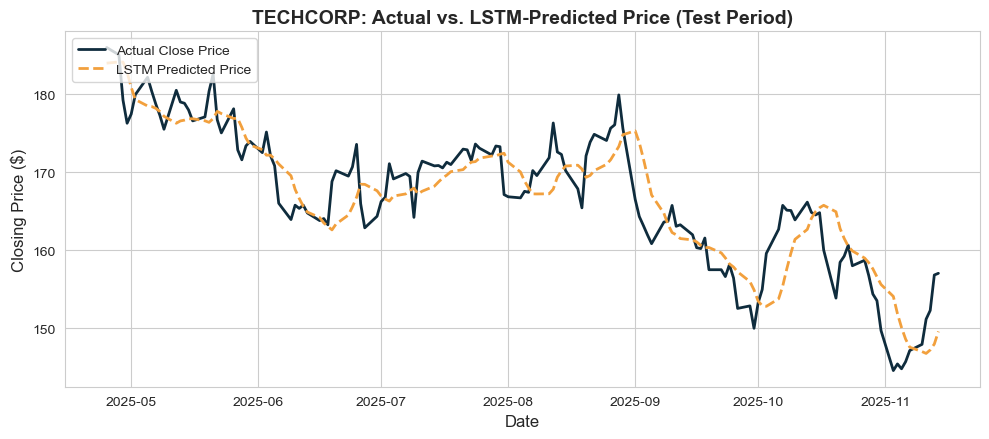

In [21]:
sns.set_style('whitegrid')

# 1. Plotting LSTM Predictions vs Actual

test_dates = techcorp['date'].values[WINDOW + split_idx:]

plt.figure(figsize=(10, 4.5))
plt.plot(test_dates, lstm_actual, label='Actual Close Price', color='#0F2C3D', linewidth=2)
plt.plot(test_dates, lstm_preds, label='LSTM Predicted Price', color='#F2A03D', linewidth=2, linestyle='--')
plt.title('TECHCORP: Actual vs. LSTM-Predicted Price (Test Period)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('outputs/lstm_price_prediction.png', dpi=300)
plt.show()

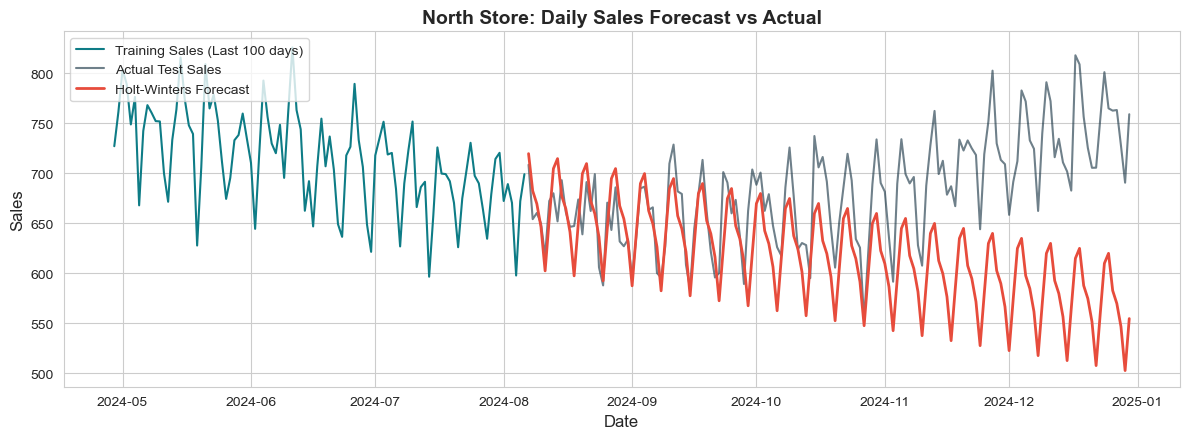

In [23]:
# 2. Plotting Holt-Winters Sales Forecast
plt.figure(figsize=(12, 4.5))
# Plot last 100 days of training data for context
plt.plot(train_sales.index[-100:], train_sales.values[-100:], label='Training Sales (Last 100 days)', color='#0E7C86')
plt.plot(test_sales.index, test_sales.values, label='Actual Test Sales', color='#0F2C3D', alpha=0.6)
plt.plot(test_sales.index, hw_preds, label='Holt-Winters Forecast', color='#E74C3C', linewidth=2)
plt.title('North Store: Daily Sales Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('outputs/sales_forecast.png', dpi=300)
plt.show()

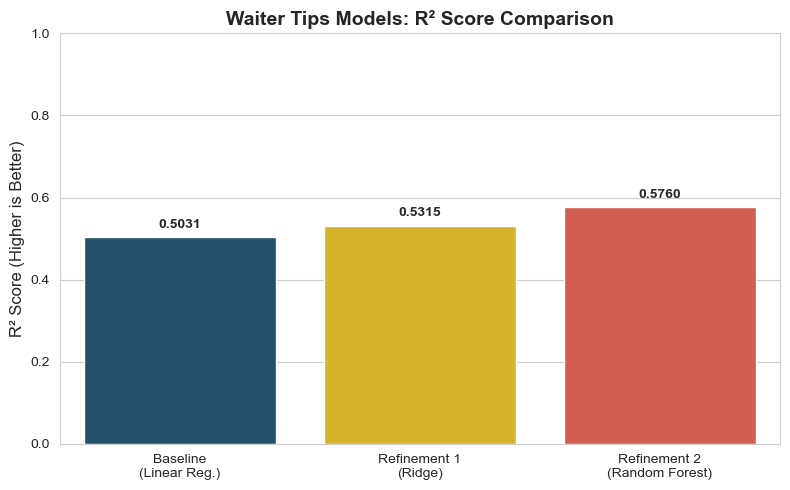

In [25]:
# 3. Plotting Waiter Tips Model Comparison (R-squared)
model_names = ['Baseline\n(Linear Reg.)', 'Refinement 1\n(Ridge)', 'Refinement 2\n(Random Forest)']
r2_scores = [base_r2, ridge_r2, rf_r2]

plt.figure(figsize=(8, 5))
bars = sns.barplot(x=model_names, y=r2_scores, palette=['#1A5276', '#F1C40F', '#E74C3C'])
plt.title('Waiter Tips Models: R² Score Comparison', fontsize=14, fontweight='bold')
plt.ylabel('R² Score (Higher is Better)', fontsize=12)
plt.ylim(0, 1.0) # R2 scores go up to 1.0

# Annotate the exact values on top of the bars
for bar in bars.patches:
    bars.annotate(f"{bar.get_height():.4f}", 
                  (bar.get_x() + bar.get_width() / 2., bar.get_height()), 
                  ha='center', va='center', 
                  xytext=(0, 9), 
                  textcoords='offset points',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/tips_model_comparison.png', dpi=300)
plt.show()